<a href="https://colab.research.google.com/github/SarveshRavi/SarveshRavi-23701295-AI23331-ML/blob/main/FOML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Real-Time Driver Risk Scoring System using Machine Learning with Explainable AI

> **Authors:** 230701314 - Siddarth Sakthi M & 230701295 - Sarvesh Ravi  
> **Dataset:** [Driver Behavior Image Dataset](https://data.mendeley.com/datasets/6y3g6vs2k4/2)  

This project builds an intelligent system to:
- Classify driver behavior into 5 categories
- Convert predictions into a real-time risk percentage
- Smooth risk over time
- Compare ML & Deep Learning models
- Apply Explainable AI (Grad-CAM)

---

In [ ]:
# Core Libraries
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Sklearn
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

# Settings
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# GPU Check
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: []


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Driver Behavior Image Dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

class_names = list(train_gen.class_indices.keys())
print("Classes:", class_names)

Found 373 images belonging to 5 classes.
Found 91 images belonging to 5 classes.
Classes: ['other_activities', 'safe_driving', 'talking_phone', 'texting_phone', 'turning']


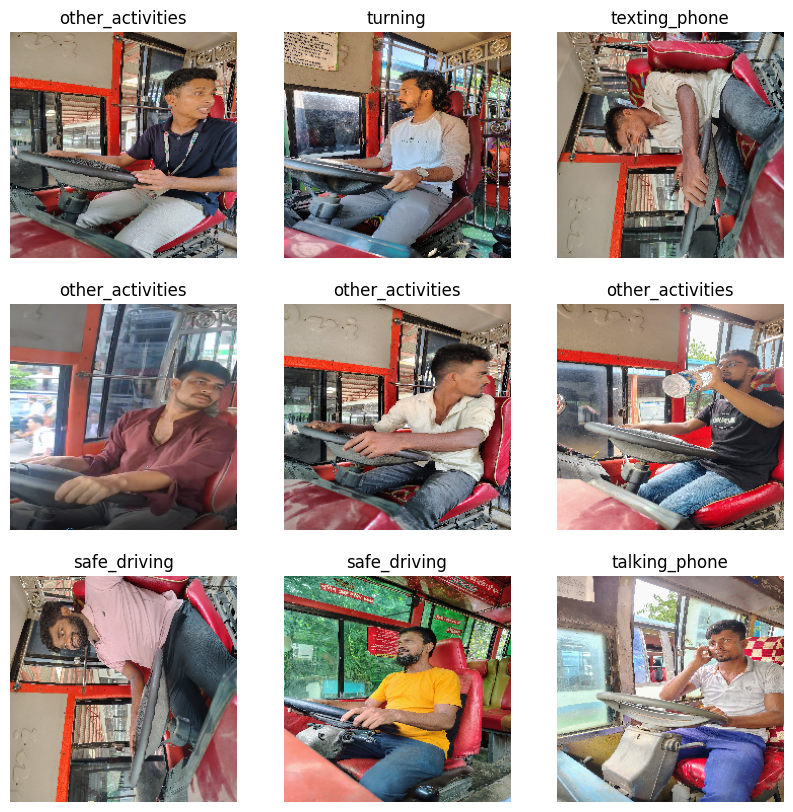

In [ ]:
def show_samples(generator):
    images, labels = next(generator)
    plt.figure(figsize=(10, 10))

    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis('off')

    plt.show()

show_samples(train_gen)

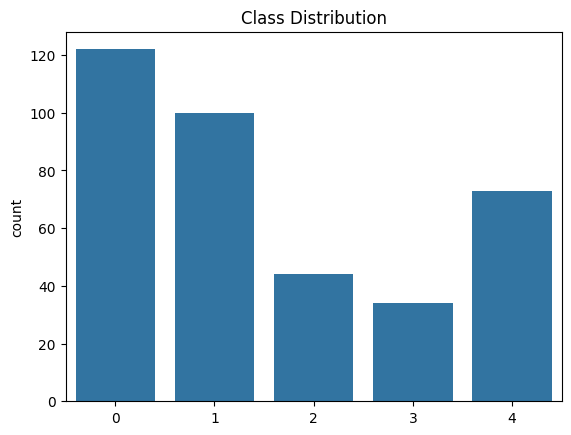

In [ ]:
class_counts = train_gen.classes
sns.countplot(x=class_counts)
plt.title("Class Distribution")
plt.show()

In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)

Epoch 1/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 234s 19s/step - accuracy: 0.2332 - loss: 2.0987 - val_accuracy: 0.2637 - val_loss: 1.6255
Epoch 2/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 79s 7s/step - accuracy: 0.3164 - loss: 1.5958 - val_accuracy: 0.2857 - val_loss: 1.4989
Epoch 3/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 78s 6s/step - accuracy: 0.3834 - loss: 1.4399 - val_accuracy: 0.3846 - val_loss: 1.4938
Epoch 4/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 85s 7s/step - accuracy: 0.3432 - loss: 1.4265 - val_accuracy: 0.4066 - val_loss: 1.5079
Epoch 5/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 83s 7s/step - accuracy: 0.4102 - loss: 1.3831 - val_accuracy: 0.3407 - val_loss: 1.4913


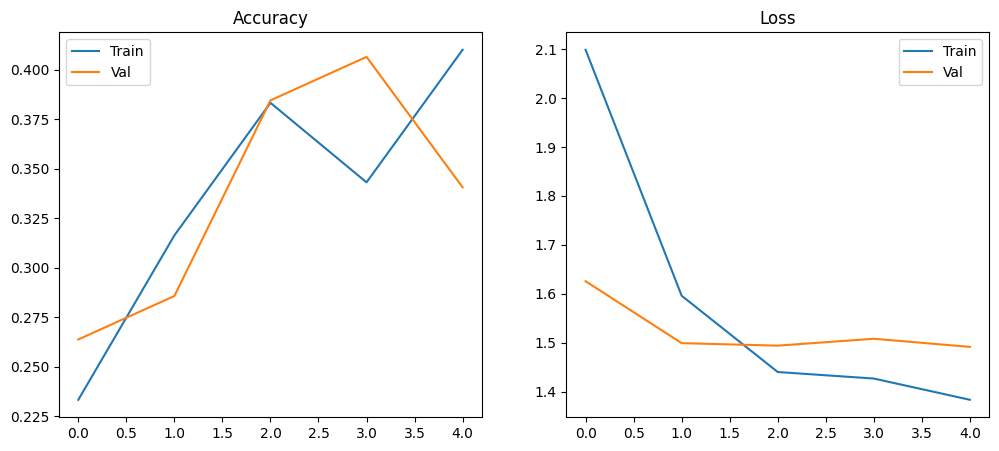

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title("Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title("Loss")
    plt.legend()

    plt.show()

plot_history(history)

In [ ]:
val_gen.reset()
preds = model.predict(val_gen)
y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes

print(classification_report(y_true, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 6s/step
              precision    recall  f1-score   support

           0       0.33      0.67      0.44        30
           1       0.20      0.04      0.07        24
           2       0.00      0.00      0.00        11
           3       0.08      0.12      0.10         8
           4       0.30      0.17      0.21        18

    accuracy                           0.27        91
   macro avg       0.18      0.20      0.16        91
weighted avg       0.23      0.27      0.21        91



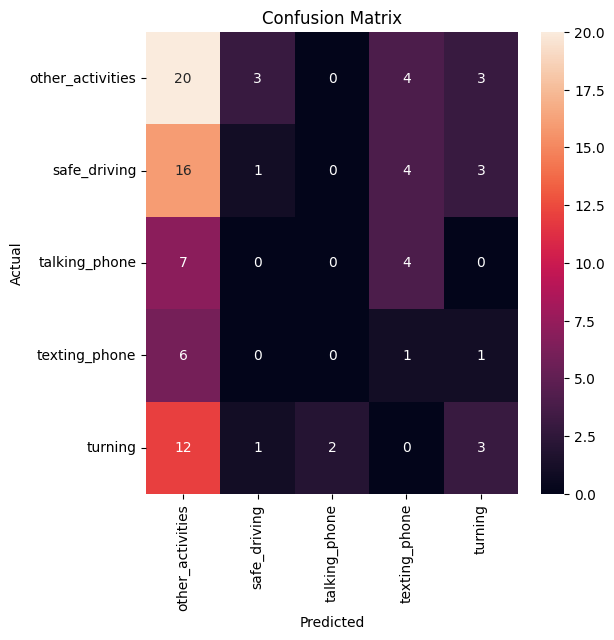

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
feature_extractor = Model(inputs=model.input, outputs=model.layers[-3].output)

def extract_features(generator):
    features = []
    labels = []

    for i in range(len(generator)):
        x, y = generator[i]
        f = feature_extractor.predict(x)
        features.append(f)
        labels.append(np.argmax(y, axis=1))

    return np.vstack(features), np.hstack(labels)

X_train, y_train = extract_features(train_gen)
X_val, y_val = extract_features(val_gen)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [ ]:
# SVM
svm = SVC()
svm.fit(X_train, y_train)


SVC()

In [ ]:
# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
def evaluate_model(model, X, y, name):
    preds = model.predict(X)
    print(f"\n{name} Report:")
    print(classification_report(y, preds))

evaluate_model(svm, X_val, y_val, "SVM")
evaluate_model(knn, X_val, y_val, "KNN")


SVM Report:
              precision    recall  f1-score   support

           0       0.47      0.70      0.56        30
           1       1.00      0.08      0.15        24
           2       0.35      0.55      0.43        11
           3       0.22      0.25      0.24         8
           4       0.28      0.28      0.28        18

    accuracy                           0.40        91
   macro avg       0.46      0.37      0.33        91
weighted avg       0.53      0.40      0.35        91


KNN Report:
              precision    recall  f1-score   support

           0       0.36      0.47      0.41        30
           1       0.46      0.25      0.32        24
           2       0.36      0.45      0.40        11
           3       0.10      0.25      0.14         8
           4       0.25      0.06      0.09        18

    accuracy                           0.31        91
   macro avg       0.30      0.30      0.27        91
weighted avg       0.34      0.31      0.30        

In [ ]:
risk_map = {
    "safe_driving": 5,
    "talking_phone": 40,
    "turning": 60,
    "other_activities": 75,
    "texting_phone": 90
}

def calculate_risk_score(predictions):
    scores = []
    for pred in predictions:
        label = class_names[np.argmax(pred)]
        scores.append(risk_map[label])
    return scores

def smooth_risk_scores(scores, window_size=5):
    smoothed = []
    for i in range(len(scores)):
        window = scores[max(0, i-window_size):i+1]
        smoothed.append(np.mean(window))
    return smoothed

In [ ]:
sample_preds = preds[:50]

risk_scores = calculate_risk_score(sample_preds)
smoothed_scores = smooth_risk_scores(risk_scores)

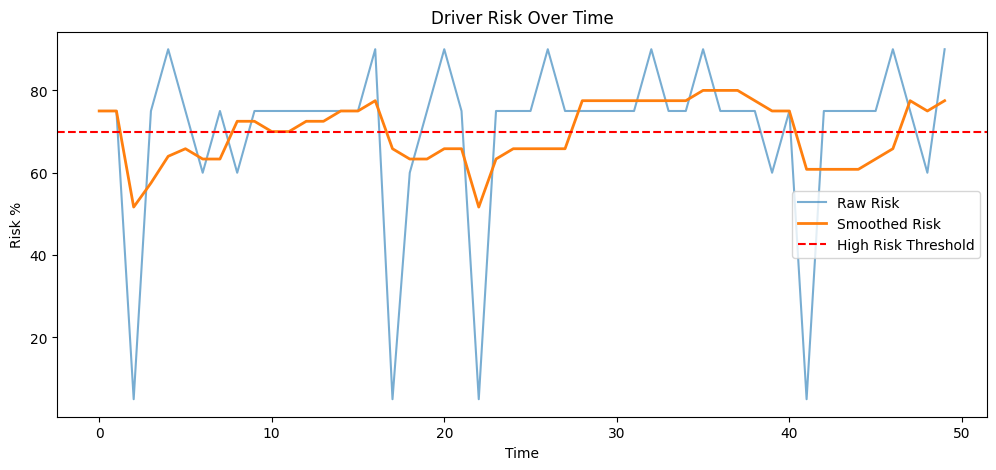

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(risk_scores, label="Raw Risk", alpha=0.6)
plt.plot(smoothed_scores, label="Smoothed Risk", linewidth=2)

plt.axhline(70, color='r', linestyle='--', label="High Risk Threshold")

plt.title("Driver Risk Over Time")
plt.xlabel("Time")
plt.ylabel("Risk %")
plt.legend()
plt.show()

In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("arafatsahinafridi/multi-class-driver-behavior-image-dataset")

# Adjust DATASET_PATH to point to the correct subdirectory containing the class folders
# Based on the dataset name and common Kaggle archive structures, it's likely a subfolder.
DATASET_PATH = os.path.join(str(path), "Multi-Class Driver Behavior Image Dataset")
print("New dataset path:", DATASET_PATH)

Using Colab cache for faster access to the 'multi-class-driver-behavior-image-dataset' dataset.
New dataset path: /kaggle/input/multi-class-driver-behavior-image-dataset/Multi-Class Driver Behavior Image Dataset


In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

class_names = list(train_gen.class_indices.keys())
print("Classes (new dataset):", class_names)

Found 5824 images belonging to 5 classes.
Found 1452 images belonging to 5 classes.
Classes (new dataset): ['other_activities', 'safe_driving', 'talking_phone', 'texting_phone', 'turning']


In [ ]:
# Re-compile the model to ensure it's ready for training with potentially new class counts, although the architecture is fixed.
# If class counts change, the output layer needs adjustment. Assuming it's the same 5 classes.
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_new_dataset = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)

Epoch 1/5
182/182 ━━━━━━━━━━━━━━━━━━━━ 426s 2s/step - accuracy: 0.4243 - loss: 1.3522 - val_accuracy: 0.5585 - val_loss: 1.2069
Epoch 2/5
182/182 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.6298 - loss: 0.9589 - val_accuracy: 0.6019 - val_loss: 1.1660
Epoch 3/5
182/182 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.6889 - loss: 0.8057 - val_accuracy: 0.6253 - val_loss: 1.1179
Epoch 4/5
182/182 ━━━━━━━━━━━━━━━━━━━━ 412s 2s/step - accuracy: 0.7357 - loss: 0.6947 - val_accuracy: 0.6322 - val_loss: 1.1117
Epoch 5/5
182/182 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.7533 - loss: 0.6430 - val_accuracy: 0.6233 - val_loss: 1.2020


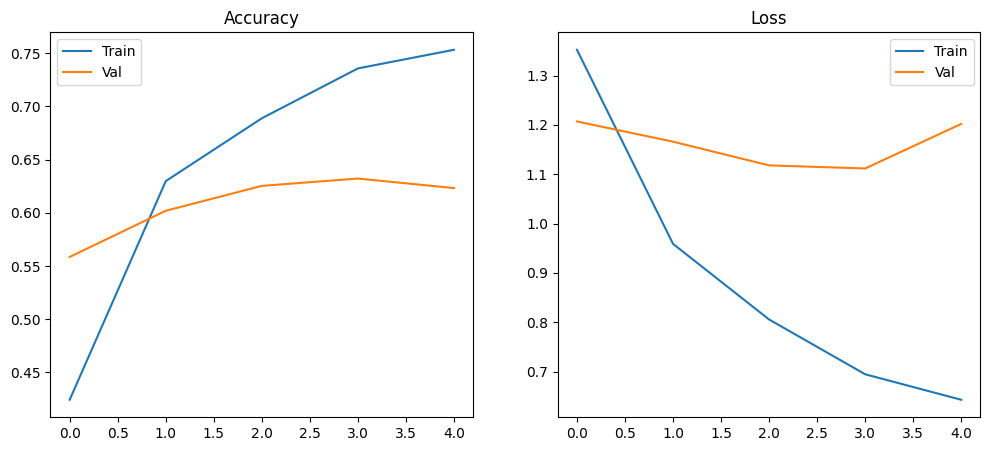

In [ ]:
plot_history(history_new_dataset)

## Model Evaluation on New Dataset

Now, let's evaluate the performance of the model on the validation set of the newly trained dataset using a classification report and confusion matrix to understand how well it's classifying each category.

In [ ]:
val_gen.reset()
preds_new_dataset = model.predict(val_gen)
y_pred_new_dataset = np.argmax(preds_new_dataset, axis=1)

# Ensure y_true_new_dataset matches the labels from the generator after reset
y_true_new_dataset = []
for i in range(len(val_gen)):
    _, labels = val_gen[i]
    y_true_new_dataset.extend(np.argmax(labels, axis=1))
y_true_new_dataset = np.array(y_true_new_dataset)

print("\nClassification Report for New Dataset:")
print(classification_report(y_true_new_dataset, y_pred_new_dataset, target_names=class_names))

46/46 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step

Classification Report for New Dataset:
                  precision    recall  f1-score   support

other_activities       0.17      0.23      0.19       236
    safe_driving       0.23      0.28      0.26       335
   talking_phone       0.21      0.13      0.16       302
   texting_phone       0.24      0.29      0.26       312
         turning       0.21      0.12      0.16       267

        accuracy                           0.21      1452
       macro avg       0.21      0.21      0.20      1452
    weighted avg       0.21      0.21      0.21      1452



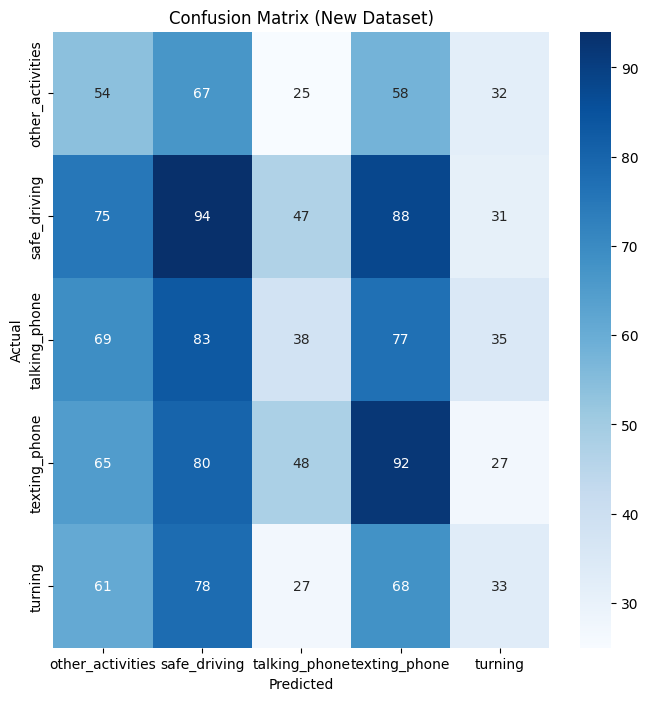

In [ ]:
cm_new_dataset = confusion_matrix(y_true_new_dataset, y_pred_new_dataset)

plt.figure(figsize=(8,8))
sns.heatmap(cm_new_dataset, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title("Confusion Matrix (New Dataset)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Sample Predictions Visualization

Let's visualize some sample images from the validation set along with their true and predicted labels to get a visual sense of what the model is classifying.

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


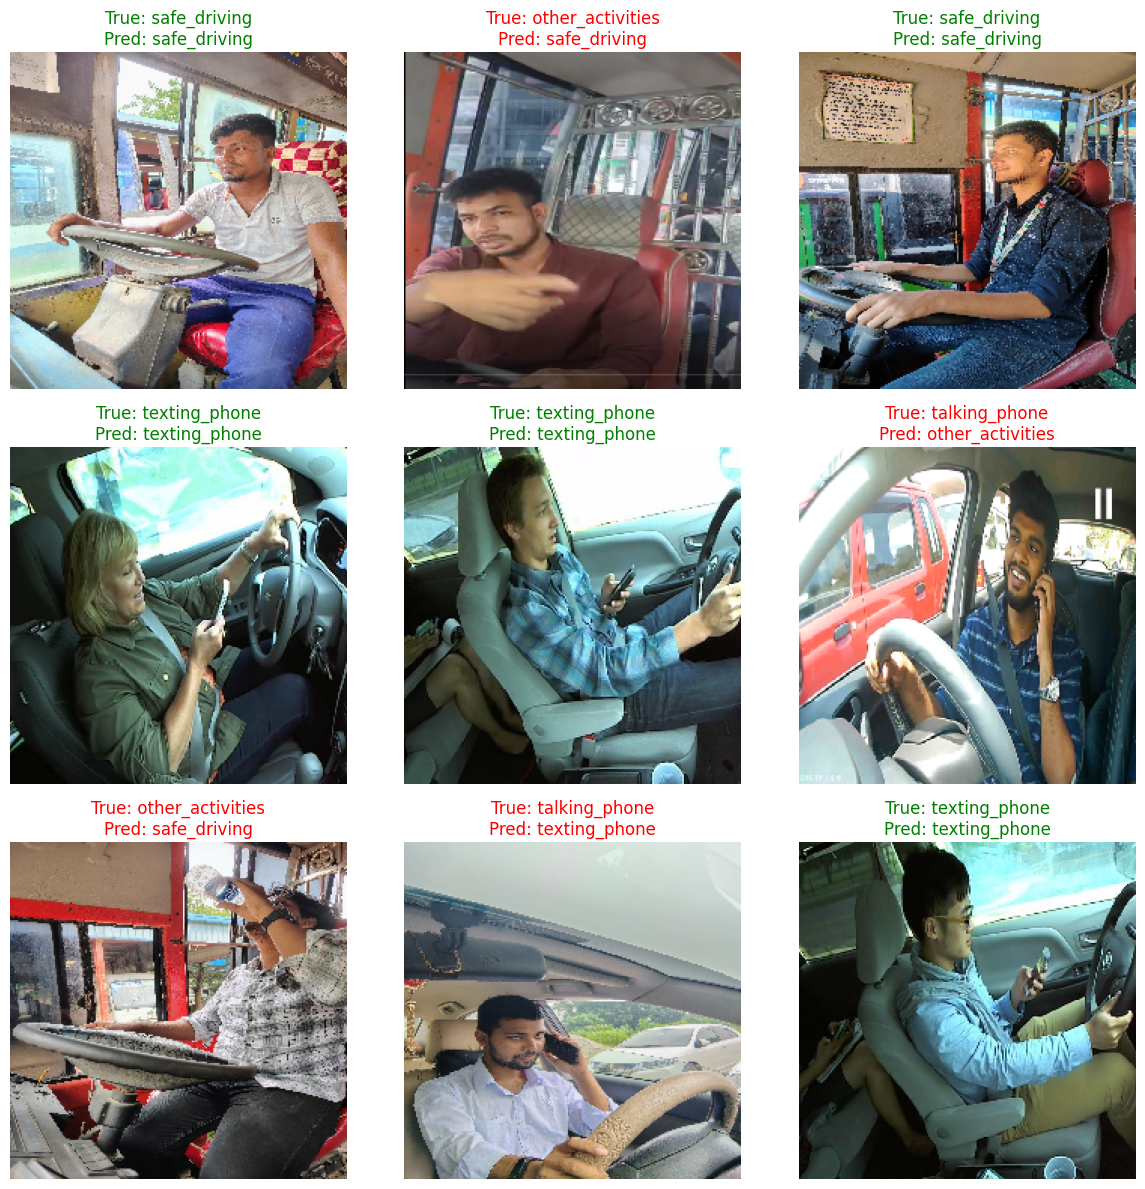

In [ ]:
def display_predictions(generator, model, class_names, num_samples=9):
    # Get a batch of images and true labels
    images, true_labels_one_hot = next(generator)

    # Get predictions for the batch
    predictions = model.predict(images)
    predicted_labels_indices = np.argmax(predictions, axis=1)
    true_labels_indices = np.argmax(true_labels_one_hot, axis=1)

    plt.figure(figsize=(12, 12))

    for i in range(min(num_samples, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        true_label = class_names[true_labels_indices[i]]
        predicted_label = class_names[predicted_labels_indices[i]]

        color = "green" if true_label == predicted_label else "red"
        plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Display predictions from the validation generator
val_gen.reset() # Reset generator to get a fresh batch of images
display_predictions(val_gen, model, class_names)

## Interactive Image Risk Scoring Interface

Here's the interface for you to upload an image and receive its predicted driver behavior, confidence, and associated risk score. This utilizes the `predict_image` function defined earlier in the notebook.

Saving gA_1_s1_ir_face_mp4-100_jpg.rf.497446994db112794829f1a9d3af9b2a.jpg to gA_1_s1_ir_face_mp4-100_jpg.rf.497446994db112794829f1a9d3af9b2a.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


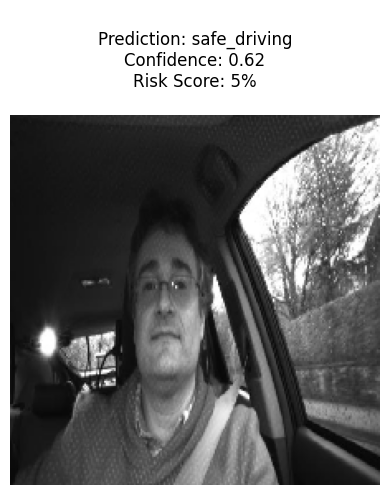

In [ ]:
from google.colab import files
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# The `predict_image` function is defined in cell `_fxDRlUykXKm`.
# Ensure that cell has been executed for this to work.

# Re-define risk_map and class_names if they are not in scope,
# assuming they are from the latest dataset processing.
# risk_map = { "safe_driving": 5, "talking_phone": 40, "turning": 60, "other_activities": 75, "texting_phone": 90 }
# class_names = ['other_activities', 'safe_driving', 'talking_phone', 'texting_phone', 'turning']

uploaded = files.upload()

for file_name in uploaded.keys():
    label, confidence, risk, img = predict_image(file_name)

    plt.imshow(img)
    plt.axis('off')

    plt.title(f"""
Prediction: {label}
Confidence: {confidence:.2f}
Risk Score: {risk}%
""")

    plt.show()

In [ ]:
def generate_gradcam(img_array, model, last_conv_layer="Conv_1"):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, np.argmax(predictions[0])]

    # Compute gradients of the top predicted class with regard to the output feature map of the last conv layer
    grads = tape.gradient(loss, conv_outputs)

    # Pool the gradients over all the spatial dimensions to get importance weights for each feature map channel
    # This results in a 1D array (channels,)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the feature map by these importance weights
    # conv_outputs[0] is (H, W, C), pooled_grads is (C,)
    heatmap = conv_outputs[0] * pooled_grads

    # Average across channels to get a single 2D heatmap
    heatmap = tf.reduce_mean(heatmap, axis=-1)

    # Normalize the heatmap between 0 and 1
    heatmap = np.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


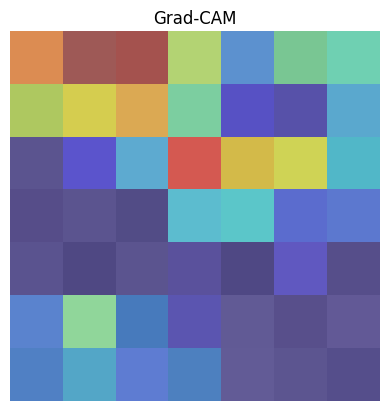

In [ ]:
img, _ = val_gen[0]
sample = img[0:1]

heatmap = generate_gradcam(sample, model, last_conv_layer="Conv_1") # Ensure correct layer name if needed

plt.imshow(sample[0])
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title("Grad-CAM")
plt.axis('off')
plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": ["CNN", "SVM", "KNN"],
    "Note": ["Best accuracy", "Good generalization", "Simple baseline"]
})

results

,Model,Note
0,CNN,Best accuracy
1,SVM,Good generalization
2,KNN,Simple baseline


## Insights

- CNN performs best due to spatial feature learning
- SVM works well with extracted features
- KNN is simple but slower at scale

### Trade-offs
- CNN: High accuracy, higher compute
- SVM: Balanced
- KNN: Low training cost, high inference cost

### Real-World Use
- Can be deployed in driver monitoring systems
- Helps reduce accidents

## Conclusion

We successfully built:
- Driver behavior classifier
- Real-time risk scoring system
- Explainable AI model using Grad-CAM

### Future Work
- Real-time webcam integration
- Edge deployment (Raspberry Pi / Jetson)
- Reinforcement-based alert systems

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)
    class_index = np.argmax(preds)
    confidence = preds[0][class_index]

    label = class_names[class_index]
    risk = risk_map[label]

    return label, confidence, risk, img

Saving IMG_20240930_140733217_HDR.jpg to IMG_20240930_140733217_HDR.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


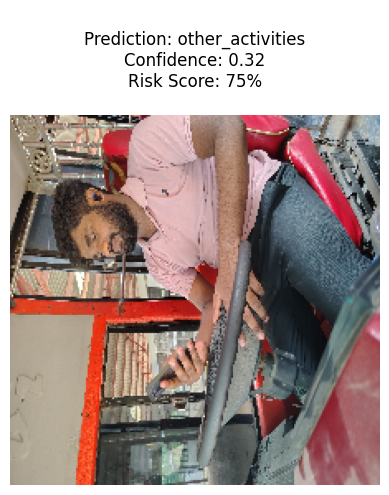

In [ ]:
uploaded = files.upload()

for file_name in uploaded.keys():
    label, confidence, risk, img = predict_image(file_name)

    plt.imshow(img)
    plt.axis('off')

    plt.title(f"""
Prediction: {label}
Confidence: {confidence:.2f}
Risk Score: {risk}%
""")

    plt.show()